# 03_Executive_Overview

## Ziel

Dieses Notebook gibt einen klaren Management-Überblick über die Performance des Olist-Marktplatzes.

**KPI-Struktur:**
- Umsatz und Wachstum
- Kundenbasis
- Kundenzufriedenheit
- Lieferperformance
- Operative Stabilität

**Begriffe kurz erklärt:**
- Wiederkaufrate: Anteil der Kunden mit mindestens zwei Bestellungen.
- Anteil negativer Bewertungen: Anteil der Bewertungen unter 3 Sternen.
- Anteil verspäteter Lieferungen: Lieferungen nach dem geplanten Termin.
- Anteil stark verspäteter Lieferungen: Lieferungen mit mehr als 7 Tagen Verspätung.
- Umsatzrealisierung: Anteil des Umsatzes aus tatsächlich gelieferten Bestellungen.
- Zahlungsabdeckung: Verhältnis aus bezahltem Betrag und Bestellwert.

**So liest man die Werte:**
- Bei Umsatz- und Qualitäts-KPI ist ein höherer Wert meist besser.
- Bei Risiko-KPI (z. B. Storno, verspätete Lieferungen) ist ein niedrigerer Wert besser.

Es werden nur aggregierte Kennzahlen gezeigt.
Detailanalysen folgen in den jeweiligen Fach-Notebooks.


## 1. Datenbasis vorbereiten


In [58]:
# Module importieren
import duckdb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Datenbank verbinden
database_path = Path("../data/processed/olist.duckdb").resolve()
db_connection = duckdb.connect(database_path.as_posix())

# SQL-Helfer
def sql(query: str):
    return db_connection.execute(query).df()

In [59]:
# Verfügbare Tabellen prüfen
sql("SHOW TABLES")

,name
0,customer_rfm
1,customers
2,geolocation
3,order_items
4,order_payments
5,order_reviews
6,orders
7,product_category
8,product_category_name_translation
9,products


## 2. Umsatz & Wachstum


### 2.1 Gesamtumsatz & Bestellungen


In [60]:
# Zentrale Umsatz-KPI berechnen (inkl. Median-Bestellwert)
kpi_revenue = sql("""
WITH order_values AS (
    SELECT
        order_id,
        MAX(customer_unique_id) AS customer_unique_id,
        SUM(price) AS order_value
    FROM customer_rfm
    GROUP BY order_id
)
SELECT
    COUNT(*) AS total_orders,
    COUNT(DISTINCT customer_unique_id) AS total_customers,
    SUM(order_value) AS total_revenue,
    AVG(order_value) AS avg_order_value,
    MEDIAN(order_value) AS median_order_value,
    SUM(order_value) / COUNT(DISTINCT customer_unique_id) AS revenue_per_customer
FROM order_values
""")

kpi_revenue

,total_orders,total_customers,total_revenue,avg_order_value,median_order_value,revenue_per_customer
0,98199,94983,1.260189e+07,128.330145,79.900002,132.675236


**Kurzinterpretation:**
- Neben dem Durchschnitt wird jetzt auch der Median-Bestellwert ausgewiesen (robuster gegen Ausreißer).
- Der durchschnittliche Bestellwert liegt bei ca. 128 R$.
- Der Umsatz pro Kunde liegt nur leicht darüber. Das spricht für wenige Wiederkäufe.
- Die Kundenbasis ist fast so groß wie die Anzahl der Bestellungen. Auch das passt zu einer niedrigen Wiederkaufrate.


### 2.2 Umsatzentwicklung


In [61]:
# Umsatzentwicklung nach Jahr und Monat berechnen
kpi_revenue_trend = sql("""
SELECT
    EXTRACT(YEAR FROM order_approved_at) AS year,
    EXTRACT(MONTH FROM order_approved_at) AS month,
    COUNT(DISTINCT order_id) AS orders,
    SUM(price) AS revenue
FROM customer_rfm
GROUP BY year, month
ORDER BY year, month
""")

kpi_revenue_trend

,year,month,orders,revenue
0,2016,9,1,44.990002
1,2016,10,291,41145.579824
2,2016,12,1,10.900000
3,2017,1,752,105205.699858
4,2017,2,1715,233113.309725
5,2017,3,2626,342432.209487
6,2017,4,2352,330573.169672
7,2017,5,3642,475245.039385
8,2017,6,3214,413815.060120
9,2017,7,3899,455009.900194


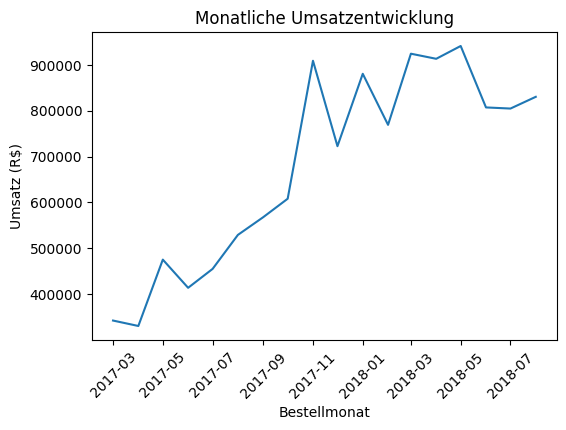

In [62]:
# Umsatzentwicklung visualisieren
kpi_revenue_trend["date"] = pd.to_datetime(
                            {
                            "year": kpi_revenue_trend["year"].astype(int),
                            "month": kpi_revenue_trend["month"].astype(int),
                            "day": 1,
                            }
                                        )

# Plot-Zeitraum begrenzen: März 2017 bis August 2018
plot_start = pd.Timestamp("2017-03-01")
plot_end = pd.Timestamp("2018-08-01")
kpi_revenue_trend_plot = kpi_revenue_trend[
    (kpi_revenue_trend["date"] >= plot_start)
    & (kpi_revenue_trend["date"] <= plot_end)
].copy()

# Umsatzentwicklung plotten
plt.figure(figsize=(6, 4))
plt.plot(kpi_revenue_trend_plot["date"], kpi_revenue_trend_plot["revenue"])
plt.title("Monatliche Umsatzentwicklung")
plt.xlabel("Bestellmonat")
plt.ylabel("Umsatz (R$)")
plt.xticks(rotation=45)
plt.show()

**Kurzinterpretation:**
- Der Umsatz steigt über den Beobachtungszeitraum deutlich an.
- 2018 liegt das Umsatzniveau über 2017.

## 3. Kundenbasis


### 3.1 Anzahl aktiver Kunden


In [63]:
# Anzahl aktiver Kunden berechnen
kpi_active_customers = sql("""
                    SELECT COUNT(DISTINCT customer_id) AS unique_customers
                    FROM customers
                    """)

kpi_active_customers

,unique_customers
0,99441


**Kurzinterpretation:**
- Die Kennzahl zeigt die Breite der aktuellen Kundenbasis.
- Zusammen mit der Wiederkaufrate wird sichtbar, ob Wachstum eher von neuen oder bestehenden Kunden kommt.


### 3.2 Wiederkaufrate


In [64]:
# Wiederkaufrate berechnen
kpi_repeat_purchase_rate = sql("""
                SELECT AVG((order_count >= 2)::INTEGER) AS repeat_rate
                FROM (
                    SELECT customer_unique_id, COUNT(*) AS order_count
                    FROM customer_rfm
                    GROUP BY customer_unique_id
                    ) AS customer_orders
                                """)

kpi_repeat_purchase_rate

,repeat_rate
0,0.054757


**Kurzinterpretation:**
- Eine niedrige Wiederkaufrate bedeutet: Viele Kunden kaufen nur einmal.
- Eine steigende Wiederkaufrate wäre ein Signal für bessere Kundenbindung.


## 4. Kundenzufriedenheit


### 4.1 Durchschnittlicher Review Score


In [65]:
# Durchschnittliche Bewertung inkl. Basisgröße berechnen
kpi_average_rating = sql("""
                WITH review_base AS (
                    SELECT
                        order_id,
                        MAX(review_score) AS review_score
                    FROM service_analyse
                    GROUP BY order_id
                )
                SELECT
                    COUNT(*) AS total_orders,
                    COUNT(CASE WHEN review_score IS NOT NULL THEN 1 END) AS rated_orders,
                    AVG(review_score) AS avg_rating
                FROM review_base
                """)

kpi_average_rating

,total_orders,rated_orders,avg_rating
0,94489,94489,4.159606


**Kurzinterpretation:**
- Der durchschnittliche Bewertungswert zeigt die allgemeine Kundenzufriedenheit.
- Zusaetzlich wird die Basis ausgewiesen (bewertete Bestellungen und Review-Abdeckung), damit der Score einordenbar ist.
- Werte deutlich unter 4 sollten als Qualitaetsrisiko beobachtet werden.


### 4.2 Anteil negativer Bewertungen

**Was die KPI zeigt:** Wie hoch der Anteil der Bewertungen unter 3 Sternen ist.
Ein niedriger Wert ist hier besser.


In [66]:
# Negativrate inkl. absoluter Fallzahl berechnen
kpi_negative_rating_rate = sql("""
                WITH review_base AS (
                    SELECT
                        order_id,
                        MAX(review_score) AS review_score
                    FROM service_analyse
                    GROUP BY order_id
                )
                SELECT
                    COUNT(CASE WHEN review_score IS NOT NULL THEN 1 END) AS rated_orders,
                    COUNT(CASE WHEN review_score < 3 THEN 1 END) AS low_rating_count,
                    COUNT(CASE WHEN review_score < 3 THEN 1 END) * 1.0
                        / NULLIF(COUNT(CASE WHEN review_score IS NOT NULL THEN 1 END), 0) AS low_rating_rate
                FROM review_base
                """)

kpi_negative_rating_rate

,rated_orders,low_rating_count,low_rating_rate
0,94489,12010,0.127105


**Kurzinterpretation:**
- Der Anteil negativer Bewertungen zeigt konkrete Problemerlebnisse.
- Zusätzlich wird die absolute Anzahl negativer Bewertungen ausgewiesen.
- Dadurch ist klar, wie gross das Problem relativ und absolut ist.


## 5. Lieferperformance


### 5.1 Durchschnittliche Lieferdauer


In [67]:
# Durchschnittliche Lieferdauer berechnen
kpi_average_delivery_time = sql("""
SELECT AVG(date_diff('day', order_purchase_timestamp, order_delivered_customer_date)) AS avg_delivery_days
FROM orders
WHERE order_status = 'delivered'
  AND order_purchase_timestamp IS NOT NULL
  AND order_delivered_customer_date IS NOT NULL
""")

kpi_average_delivery_time

,avg_delivery_days
0,12.496849


**Kurzinterpretation:**
- Die durchschnittliche Lieferdauer beträgt 12,5 Tage.
- Für Entscheidungen sollte sie immer mit der Verspätungsquote zusammen gelesen werden.


### 5.2 Anteil verspäteter Lieferungen


In [68]:
# Anteil verspäteter Lieferungen berechnen
kpi_late_delivery = sql("""
SELECT AVG((order_delivered_customer_date > order_estimated_delivery_date)::INTEGER) AS late_delivery_rate
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL
""")

kpi_late_delivery

,late_delivery_rate
0,0.081124


**Kurzinterpretation:**
- Die Verspätungsquote zeigt, wie verlässlich Liefertermine eingehalten werden.
- Hohe Werte wirken direkt auf Kundenzufriedenheit und Wiederkauf.


### 5.3 Anteil stark verspäteter Lieferungen (>7 Tage)

**Was die KPI zeigt:** Wie oft Lieferungen mehr als 7 Tage nach dem geplanten Termin ankommen.
Ein niedriger Wert ist hier besser.


In [69]:
# Anteil stark verspäteter Lieferungen und mittlere Verspätung berechnen
kpi_late_delivery_over_7_days = sql("""
WITH delivered AS (
    SELECT date_diff('day', order_estimated_delivery_date, order_delivered_customer_date) AS delay_days
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
                  )
SELECT
    AVG((delay_days > 7)::INTEGER) AS late_over_7_days_rate,
    AVG(CASE WHEN delay_days > 0 THEN delay_days END) AS avg_delay_days_if_late
FROM delivered
""")

kpi_late_delivery_over_7_days

,late_over_7_days_rate,avg_delay_days_if_late
0,0.029667,10.620141


**Kurzinterpretation:**
- Der Anteil stark verspäteter Lieferungen zeigt die kritischsten Lieferprobleme.
- Die durchschnittliche Verspätung bei verspäteten Lieferungen zeigt, wie groß das Problem im Mittel ist.


## 6. Ergänzende Executive-KPIs

Diese KPI zeigen zusätzlich, wie stabil der Betrieb läuft.
So sieht man besser, ob Wachstum auch sauber umgesetzt wird.


### 6.1 Storno- und Erfüllungsquote

**Was die KPI zeigt:** Wie viele Bestellungen storniert oder nicht erfüllt werden.


In [70]:
# Stornoquote und Nichterfüllungsquote berechnen
kpi_order_fulfillment = sql("""
SELECT
    COUNT(*) AS total_orders,
    AVG((order_status = 'canceled')::INTEGER) AS cancel_rate,
    AVG((order_status IN ('canceled', 'unavailable'))::INTEGER) AS non_fulfillment_rate
FROM orders
""")

kpi_order_fulfillment

,total_orders,cancel_rate,non_fulfillment_rate
0,99441,0.006285,0.012409


**Kurzinterpretation:**
- Stornoquote: Anteil stornierter Bestellungen.
- Nichterfüllungsquote: Anteil nicht erfüllter Bestellungen (inklusive "unavailable").
- Beide Werte sollten möglichst niedrig sein.


### 6.2 Umsatzrealisierung (gelieferte Bestellungen)

**Was die KPI zeigt:** Wie viel vom Artikelumsatz wirklich aus gelieferten Bestellungen kommt.


In [71]:
# Umsatzanteil aus gelieferten Bestellungen berechnen
# 1) Gesamten Artikelumsatz holen
# 2) Artikelumsatz aus gelieferten Bestellungen holen
# 3) Quote in Python berechnen

kpi_revenue_realization = sql("""
SELECT
    (SELECT SUM(price) FROM order_items) AS total_item_value,
    (
        SELECT SUM(order_items_table.price)
        FROM order_items AS order_items_table
        INNER JOIN orders AS orders_table
            ON order_items_table.order_id = orders_table.order_id
        WHERE orders_table.order_status = 'delivered'
    ) AS delivered_item_value
""")

kpi_revenue_realization["revenue_realization_rate"] = (
    kpi_revenue_realization["delivered_item_value"] / kpi_revenue_realization["total_item_value"]
)

kpi_revenue_realization

,total_item_value,delivered_item_value,revenue_realization_rate
0,1.359164e+07,1.322150e+07,0.972767


**Kurzinterpretation:**
- Ein hoher Wert bedeutet: Ein großer Teil des Umsatzes wird wirklich geliefert.
- Ein niedriger Wert bedeutet: Umsatz geht durch Ausfälle verloren.


### 6.3 Zahlungsabdeckung

**Was die KPI zeigt:** Verhältnis aus gesamter Zahlungssumme und gesamtem Bestellwert.
Ein Wert nahe 100 % bedeutet: Zahlungen und Bestellwerte passen insgesamt gut zusammen.


In [72]:
# Zahlungsabdeckung einfach berechnen
# Gesamtzahlungen und Gesamtbestellwert vergleichen

kpi_payment_coverage = sql("""
WITH order_value_per_order AS (
    SELECT order_id, SUM(price + freight_value) AS order_value_total
    FROM order_items
    GROUP BY order_id
),
payment_per_order AS (
    SELECT order_id, SUM(payment_value) AS payment_total
    FROM order_payments
    GROUP BY order_id
)
SELECT
    SUM(payment_per_order.payment_total) AS total_paid_value,
    SUM(order_value_per_order.order_value_total) AS total_order_value
FROM order_value_per_order
INNER JOIN payment_per_order
    ON order_value_per_order.order_id = payment_per_order.order_id
""")

kpi_payment_coverage["payment_to_order_value_ratio"] = (
    kpi_payment_coverage["total_paid_value"] / kpi_payment_coverage["total_order_value"]
)

kpi_payment_coverage

,total_paid_value,total_order_value,payment_to_order_value_ratio
0,15846280.17,15843409.78,1.000181


**Kurzinterpretation:**
- Werte nahe 100 % bedeuten: Zahlungen passen insgesamt gut zu den Bestellwerten.
- Deutlich niedrigere Werte deuten auf Abweichungen hin (z. B. Rückerstattungen).


### 6.4 Umsatzkonzentration (Top-Kategorien)

**Was die KPI zeigt:** Ob viel Umsatz von wenigen Kategorien abhängt.


In [73]:
# Umsatzkonzentration der Top-Kategorien berechnen
# 1) Umsatz je Kategorie berechnen
# 2) Gesamtumsatz, Top-5-Umsatz und Top-1-Umsatz in Python bestimmen

category_revenue = sql("""
SELECT
    products_table.product_category_name AS category,
    SUM(order_items_table.price) AS revenue
FROM order_items AS order_items_table
INNER JOIN products AS products_table
    ON order_items_table.product_id = products_table.product_id
GROUP BY products_table.product_category_name
""")

total_revenue = category_revenue["revenue"].sum()
top5_revenue = category_revenue.sort_values("revenue", ascending=False).head(5)["revenue"].sum()
top1_revenue = category_revenue["revenue"].max()

if total_revenue != 0:
    top5_revenue_share = top5_revenue / total_revenue
    top1_revenue_share = top1_revenue / total_revenue
else:
    top5_revenue_share = None
    top1_revenue_share = None

kpi_category_concentration = pd.DataFrame({
    "total_revenue": [total_revenue],
    "top5_revenue_share": [top5_revenue_share],
    "top1_revenue_share": [top1_revenue_share],
})

kpi_category_concentration

,total_revenue,top5_revenue_share,top1_revenue_share
0,13591643.7,0.397353,0.092607


**Kurzinterpretation:**
- Ein hoher Wert bedeutet: Hohe Abhängigkeit von wenigen Kategorien.
- Ein niedriger Wert bedeutet: Umsatz ist breiter verteilt.


## 7. Executive Summary


In [74]:
# Alle KPI in einer Management-Scorecard zusammenführen
summary_rows = [
    ("Gesamtumsatz", round(float(kpi_revenue.at[0, "total_revenue"]), 2), "R$"),
    ("Anzahl Bestellungen", int(float(kpi_revenue.at[0, "total_orders"])), "Anzahl"),
    ("Durchschnittlicher Warenkorb", round(float(kpi_revenue.at[0, "avg_order_value"]), 2), "R$"),
    ("Median Warenkorb", round(float(kpi_revenue.at[0, "median_order_value"]), 2), "R$"),
    ("Wiederkaufrate", round(float(kpi_repeat_purchase_rate.at[0, "repeat_rate"]) * 100, 2), "%"),
    ("Durchschnittlicher Review Score", round(float(kpi_average_rating.at[0, "avg_rating"]), 2), "Score"),
    ("Anteil negativer Bewertungen", round(float(kpi_negative_rating_rate.at[0, "low_rating_rate"]) * 100, 2), "%"),
    ("Durchschnittliche Lieferdauer", round(float(kpi_average_delivery_time.at[0, "avg_delivery_days"]), 2), "Tage"),
    ("Anteil verspäteter Lieferungen", round(float(kpi_late_delivery.at[0, "late_delivery_rate"]) * 100, 2), "%"),
    ("Anteil stark verspäteter Lieferungen", round(float(kpi_late_delivery_over_7_days.at[0, "late_over_7_days_rate"]) * 100, 2), "%"),
    ("Stornoquote", round(float(kpi_order_fulfillment.at[0, "cancel_rate"]) * 100, 2), "%"),
    ("Anteil nicht erfüllter Bestellungen", round(float(kpi_order_fulfillment.at[0, "non_fulfillment_rate"]) * 100, 2), "%"),
    ("Umsatzrealisierungsquote", round(float(kpi_revenue_realization.at[0, "revenue_realization_rate"]) * 100, 2), "%"),
    ("Zahlungsabdeckung", round(float(kpi_payment_coverage.at[0, "payment_to_order_value_ratio"]) * 100, 2), "%"),
    ("Umsatzanteil Top-5-Kategorien", round(float(kpi_category_concentration.at[0, "top5_revenue_share"]) * 100, 2), "%")
]

summary_kpi = pd.DataFrame(summary_rows, columns=["KPI", "Wert", "Einheit"])
summary_kpi


,KPI,Wert,Einheit
0,Gesamtumsatz,12601891.94,R$
1,Anzahl Bestellungen,98199.00,Anzahl
2,Durchschnittlicher Warenkorb,128.33,R$
3,Median Warenkorb,79.90,R$
4,Wiederkaufrate,5.48,%
5,Durchschnittlicher Review Score,4.16,Score
6,Anteil negativer Bewertungen,12.71,%
7,Durchschnittliche Lieferdauer,12.50,Tage
8,Anteil verspäteter Lieferungen,8.11,%
9,Anteil stark verspäteter Lieferungen,2.97,%


### 7.1 Kernaussagen für das Management

1. **Wachstum:** Umsatz, Bestellungen und Warenkorb zeigen das aktuelle Umsatzniveau.
2. **Kunden und Qualität:** Wiederkaufrate und Bewertungskennzahlen zeigen, wie stabil die Kundennachfrage ist.
3. **Lieferung:** Durchschnittliche Lieferdauer sowie verspätete und stark verspätete Lieferungen zeigen den operativen Servicegrad.
4. **Stabilität des Geschäfts:** Stornoquote, nicht erfüllte Bestellungen, Umsatzrealisierung und Zahlungsabdeckung zeigen Umsetzungsrisiken.
5. **Strukturrisiko:** Der Umsatzanteil der Top-5-Kategorien zeigt die Abhängigkeit von wenigen Warengruppen.

### 7.2 Kurzfazit

Die Scorecard zeigt ein wachsendes Geschäft mit klar messbaren operativen Hebeln.
Für die nächste Steuerungsrunde sollten Lieferqualität, Stornoquote und Wiederkaufrate priorisiert werden, damit Wachstum und Servicequalität gemeinsam steigen.
